# Ridge / Lasso — Anti-Money Laundering (AML)

### Contextualización Teórica
Los modelos Lineares (Ridge/Lasso Classifier) intentan trazar una matriz o frontera condicional plana e interpretable entre clases ("Transacción Ilícita" y "Transacción Normal"). La particularidad teórica indispensable es aplicar regularización para contraer (minimizar) u obviar los coeficientes de las características irrelevantes para nuestro diagnóstico. Esto previene un modelado excesivamente atado o predispuesto al ruido inherente de los datos masivos de transacciones e introduce un cortafuego contra el *overfitting*. En el entorno regulatorio AML, la claridad operativa y auditabilidad detrás de sus coeficientes (pesos exactos para cada transacción dada) lo hace preferiblemente seguro y normativo.

In [1]:
!pip install deap optuna -q

import warnings
import time
import random
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.stats import loguniform, randint

from sklearn.base            import BaseEstimator, ClassifierMixin
from sklearn.linear_model    import LogisticRegression
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import (
    TimeSeriesSplit, GridSearchCV, RandomizedSearchCV, cross_val_score
)
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve, auc,
    f1_score, roc_auc_score, accuracy_score
)

from imblearn.pipeline      import Pipeline
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.base          import BaseSampler

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from deap import base, creator, tools, algorithms

warnings.filterwarnings("ignore")
sns.set_theme(style='ticks', context='paper', font_scale=1.2, palette='Set1')

# ── Constantes globales ────────────────────────────────────────────────────────
RANDOM_STATE    = 42
N_SPLITS        = 3       # TimeSeriesSplit folds (cronológico, nunca KFold aleatorio)
N_ITER_RANDOM   = 20      # Random Search: iteraciones por estrategia de balanceo
N_TRIALS_OPTUNA = 30      # Optuna: trials totales (incluye balance como hiperparámetro)
POP_SIZE        = 10      # DEAP: tamaño de la población
N_GEN           = 5       # DEAP: número de generaciones
BASE_PATH       = '/content/drive/MyDrive/Datasets/Final Project/Processed/'

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 30.8 MB/s eta 0:00:00


## Sección 2 · Clases Auxiliares
### Justificación del espacio de hiperparámetros


In [2]:
class IdentitySampler(BaseSampler):
    """Bypass: no aplica ningún oversampling, pasa los datos tal cual."""
    _sampling_type         = "bypass"
    _parameter_constraints = {}

    def _fit_resample(self, X, y):
        return X, y

    def __repr__(self):
        return "IdentitySampler()"


class DynamicBalanceLR(BaseEstimator, ClassifierMixin):
    """
    Wrapper de LogisticRegression compatible con los cuatro solvers del entregable.

    Cuando `use_balanced_weight=True`, el parámetro `class_weight='balanced'`
    se calcula exclusivamente a partir de las etiquetas `y` recibidas en `.fit()`,
    es decir, desde el fold de entrenamiento activo → sin data leakage.

    Solvers soportados:
      - 'lbfgs'     → L2  (Ridge estándar)
      - 'saga'      → L1 y L2 (Ridge SAGA / Lasso SAGA)
      - 'liblinear' → L1  (Lasso estándar)
    """
    def __init__(self, penalty='l2', solver='lbfgs', C=1.0,
                 max_iter=1000, tol=1e-4, use_balanced_weight=False,
                 random_state=RANDOM_STATE):
        self.penalty             = penalty
        self.solver              = solver
        self.C                   = C
        self.max_iter            = max_iter
        self.tol                 = tol
        self.use_balanced_weight = use_balanced_weight
        self.random_state        = random_state
        self.model_              = None

    def fit(self, X, y, **kwargs):
        cw = 'balanced' if self.use_balanced_weight else None
        self.model_ = LogisticRegression(
            penalty      = self.penalty,
            solver       = self.solver,
            C            = self.C,
            max_iter     = self.max_iter,
            tol          = self.tol,
            class_weight = cw,
            random_state = self.random_state,
            n_jobs       = 1,   # evitar over-subscription con n_jobs=-1 en CV
        )
        self.model_.fit(X, y)
        return self

    def predict(self, X):       return self.model_.predict(X)
    def predict_proba(self, X): return self.model_.predict_proba(X)

## Sección 3 · Carga de Datos


In [3]:
from google.colab import drive
drive.mount('/content/drive')

X_train = pd.read_parquet(f'{BASE_PATH}X_train.parquet')
X_test  = pd.read_parquet(f'{BASE_PATH}X_test.parquet')
y_train = pd.read_parquet(f'{BASE_PATH}y_train.parquet')['Is Laundering']
y_test  = pd.read_parquet(f'{BASE_PATH}y_test.parquet')['Is Laundering']

print(f"X_train : {X_train.shape} | y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}  | y_test  : {y_test.shape}")
print(f"Prevalencia Lavado — Train: {y_train.mean():.4%} | Test: {y_test.mean():.4%}")

Mounted at /content/drive
X_train : (4062668, 45) | y_train : (4062668,)
X_test  : (1015668, 45)  | y_test  : (1015668,)
Prevalencia Lavado — Train: 0.0832% | Test: 0.1770%


## Sección 4 · Configuraciones Compartidas
### Configuraciones de modelo
### Espacios de búsqueda


In [31]:
TSCV = TimeSeriesSplit(n_splits=N_SPLITS)

MODEL_CONFIGS = {
    'ridge_std' : {
        'penalty': 'l2', 'solver': 'lbfgs',
        'label'  : 'Ridge (lbfgs)',
        'color'  : '#E41A1C',
    },
    'ridge_saga': {
        'penalty': 'l2', 'solver': 'saga',
        'label'  : 'Ridge (SAGA)',
        'color'  : '#377EB8',
    },
    'lasso_std' : {
        'penalty': 'l1', 'solver': 'liblinear',
        'label'  : 'Lasso (liblinear)',
        'color'  : '#4DAF4A',
    },
    'lasso_saga': {
        'penalty': 'l1', 'solver': 'saga',
        'label'  : 'Lasso (SAGA)',
        'color'  : '#FF7F00',
    },
}

BALANCE_CONFIGS = [
    {'id': 0, 'name': 'Sin balanceo',             'use_bw': False},
    {'id': 1, 'name': 'SMOTE',                     'use_bw': False},
    {'id': 2, 'name': 'ADASYN',                    'use_bw': False},
    {'id': 3, 'name': "class_weight='balanced'",   'use_bw': True },
]

# Espacio Grid: 6 × 2 = 12 combinaciones por estrategia de balanceo
PARAM_GRID_LR = {
    'clf__C'       : [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'clf__max_iter': [500, 2000],
}

# Espacio Random: distribuciones continuas (C en log-escala)
PARAM_DIST_LR = {
    'clf__C'       : loguniform(1e-3, 1e3),
    'clf__max_iter': randint(300, 5001),
}

RESULTS = {}   # Diccionario global de resultados


def get_fresh_sampler(bal_id):
    """Retorna una instancia nueva del sampler para evitar estado residual."""
    if bal_id == 1: return SMOTE(random_state=RANDOM_STATE)
    if bal_id == 2: return ADASYN(random_state=RANDOM_STATE)
    return IdentitySampler()


# ── Helpers de convergencia ────────────────────────────────────────────────────
def converged_optuna(study, patience=10):
    """True si el mejor valor acumulado no mejoró en los últimos `patience` trials."""
    vals = [t.value for t in study.trials if t.value is not None]
    if len(vals) < patience:
        return False
    best = [max(vals[:i + 1]) for i in range(len(vals))]
    return len(set(best[-patience:])) == 1


def converged_deap(logbook, patience=2):
    """True si el F1 máximo no mejoró en las últimas `patience` generaciones."""
    maxes = logbook.select('max')
    if len(maxes) <= patience:
        return False
    return maxes[-1] == maxes[-(patience + 1)]


# ── Helpers DEAP ──────────────────────────────────────────────────────────────
def decode_individual_lr(ind):
    """
    Traduce los 3 genes del individuo a parámetros de DynamicBalanceLR.

    Cromosoma:
      Gene 0 → balance_strategy  int  [0, 3]
      Gene 1 → log10(C)          float [-3, 3]  → C = 10^gene1
      Gene 2 → max_iter          int  [300, 5000]
    """
    bal_id   = int(np.clip(round(ind[0]), 0, 3))
    C        = float(10 ** np.clip(ind[1], -3, 3))
    max_iter = int(np.clip(round(ind[2]), 300, 5000))
    return bal_id, C, max_iter


def mutate_individual_lr(individual, indpb):
    """Mutación personalizada con restricciones de rango por gen."""
    if random.random() < indpb: individual[0] = random.randint(0, 3)
    if random.random() < indpb: individual[1] = random.uniform(-3, 3)
    if random.random() < indpb: individual[2] = random.randint(300, 5000)
    return individual,


def _init_deap_toolbox_lr(evaluate_fn, X_train, y_train):
    """Registra los operadores DEAP para LR y retorna el toolbox configurado."""
    if hasattr(creator, 'FitnessMax'): del creator.FitnessMax
    if hasattr(creator, 'Individual'): del creator.Individual
    creator.create('FitnessMax', base.Fitness, weights=(1.0,))
    creator.create('Individual', list,         fitness=creator.FitnessMax)

    cv      = TimeSeriesSplit(n_splits=N_SPLITS)
    toolbox = base.Toolbox()
    toolbox.register('attr_bal',      random.randint, 0, 3)
    toolbox.register('attr_C_log',    random.uniform, -3, 3)
    toolbox.register('attr_max_iter', random.randint, 300, 5000)
    toolbox.register(
        'individual', tools.initCycle, creator.Individual,
        (toolbox.attr_bal, toolbox.attr_C_log, toolbox.attr_max_iter), n=1
    )
    toolbox.register('population', tools.initRepeat, list, toolbox.individual)
    toolbox.register('evaluate', evaluate_fn, X=X_train, y=y_train, cv=cv)
    toolbox.register('mate',   tools.cxTwoPoint)
    toolbox.register('mutate', mutate_individual_lr, indpb=0.3)
    toolbox.register('select', tools.selTournament, tournsize=3)
    return toolbox


def _run_deap(toolbox, pop_size, n_gen):
    """Ejecuta eaSimple y retorna (best_ind, logbook, elapsed_min)."""
    pop   = toolbox.population(n=pop_size)
    hof   = tools.HallOfFame(1)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register('avg', np.mean)
    stats.register('max', np.max)

    t0 = time.time()
    pop, logbook = algorithms.eaSimple(
        pop, toolbox, cxpb=0.5, mutpb=0.2,
        ngen=n_gen, stats=stats, halloffame=hof, verbose=True
    )
    elapsed = (time.time() - t0) / 60
    return hof[0], logbook, elapsed


# ── Construcción del modelo final ─────────────────────────────────────────────
def build_final_model_lr(spec, X_train, y_train):
    """Reconstruye y entrena el pipeline final en todo X_train."""
    bal_cfg = BALANCE_CONFIGS[spec['bal_id']]
    sampler = get_fresh_sampler(spec['bal_id'])
    pipe = Pipeline([
        ('scaler',  StandardScaler()),
        ('sampler', sampler),
        ('clf',     DynamicBalanceLR(
                        penalty             = spec['penalty'],
                        solver              = spec['solver'],
                        C                   = spec['C'],
                        max_iter            = spec['max_iter'],
                        use_balanced_weight = bal_cfg['use_bw'],
                    )),
    ])
    pipe.fit(X_train, y_train)
    return pipe

## Sección 5 · Ridge estándar (lbfgs) — Todos los métodos de búsqueda
### 5.1 Grid Search — Ridge (lbfgs)


In [48]:
def run_grid_search_lr(model_cfg_key, X_train, y_train):
    """Grid Search genérico para cualquier configuración Ridge/Lasso."""
    cfg        = MODEL_CONFIGS[model_cfg_key]
    result_key = f"{model_cfg_key}_grid"

    n_combos = 1
    for v in PARAM_GRID_LR.values():
        n_combos *= len(v)

    print(f"{'═'*62}")
    print(f" Grid Search — {cfg['label']}")
    print(f"{'═'*62}")
    print(f" Combinaciones por estrategia : {n_combos}")
    print(f" Configs totales evaluadas    : {n_combos * len(BALANCE_CONFIGS)}")
    print(f" Fits totales (× {N_SPLITS} folds)     : {n_combos * len(BALANCE_CONFIGS) * N_SPLITS}\n")

    best_f1, best_spec, best_bal_name = -1, None, None
    t0 = time.time()

    for bal_cfg in BALANCE_CONFIGS:
        sampler = get_fresh_sampler(bal_cfg['id'])
        pipe = Pipeline([
            ('scaler',  StandardScaler()),
            ('sampler', sampler),
            ('clf',     DynamicBalanceLR(
                            penalty=cfg['penalty'],
                            solver=cfg['solver'],
                            use_balanced_weight=bal_cfg['use_bw'])),
        ])
        search = GridSearchCV(
            pipe, PARAM_GRID_LR, cv=TSCV,
            scoring='f1', n_jobs=-1, refit=False
        )
        search.fit(X_train, y_train)
        score = search.best_score_
        print(f"  [{bal_cfg['name']:35s}]  F1 CV = {score:.4f}")

        if score > best_f1:
            best_f1       = score
            best_bal_name = bal_cfg['name']
            p             = search.best_params_
            best_spec     = {
                'model_cfg': model_cfg_key,
                'penalty'  : cfg['penalty'],
                'solver'   : cfg['solver'],
                'bal_id'   : bal_cfg['id'],
                'C'        : p['clf__C'],
                'max_iter' : p['clf__max_iter'],
            }

    elapsed = (time.time() - t0) / 60
    n_evals = n_combos * len(BALANCE_CONFIGS)

    print(f"\n  ✓ Mejor F1 (CV) : {best_f1:.4f}  |  Balanceo : {best_bal_name}")
    print(f"  ✓ Tiempo total  : {elapsed:.1f} min  |  Evaluaciones : {n_evals}")

    RESULTS[result_key] = {
        'label'       : cfg['label'],
        'method'      : 'Grid Search',
        'model_cfg'   : model_cfg_key,
        'best_f1'     : round(best_f1, 4),
        'time_min'    : round(elapsed, 2),
        'n_evals'     : n_evals,
        'converged'   : 'N/A',
        'best_balance': best_bal_name,
        'spec'        : best_spec,
    }
    return RESULTS[result_key]


result_ridge_std_grid = run_grid_search_lr('ridge_std', X_search, y_search)

══════════════════════════════════════════════════════════════
 Grid Search — Ridge (lbfgs)
══════════════════════════════════════════════════════════════
 Combinaciones por estrategia : 6
 Configs totales evaluadas    : 24
 Fits totales (× 3 folds)     : 72

  [Sin balanceo                       ]  F1 CV = 0.0111
  [SMOTE                              ]  F1 CV = 0.0528
  [ADASYN                             ]  F1 CV = 0.0521
  [class_weight='balanced'            ]  F1 CV = 0.0481

  ✓ Mejor F1 (CV) : 0.0528  |  Balanceo : SMOTE
  ✓ Tiempo total  : 1.3 min  |  Evaluaciones : 24


### 5.2 Random Search — Ridge (lbfgs)


In [47]:
def run_random_search_lr(model_cfg_key, X_train, y_train, n_iter=N_ITER_RANDOM):
    """Random Search genérico para cualquier configuración Ridge/Lasso."""
    cfg        = MODEL_CONFIGS[model_cfg_key]
    result_key = f"{model_cfg_key}_random"

    print(f"{'═'*62}")
    print(f" Random Search — {cfg['label']}")
    print(f"{'═'*62}")
    print(f" Iteraciones por estrategia : {n_iter}")
    print(f" Configs totales evaluadas  : {n_iter * len(BALANCE_CONFIGS)}\n")

    best_f1, best_spec, best_bal_name = -1, None, None
    t0 = time.time()

    for bal_cfg in BALANCE_CONFIGS:
        sampler = get_fresh_sampler(bal_cfg['id'])
        pipe = Pipeline([
            ('scaler',  StandardScaler()),
            ('sampler', sampler),
            ('clf',     DynamicBalanceLR(
                            penalty=cfg['penalty'],
                            solver=cfg['solver'],
                            use_balanced_weight=bal_cfg['use_bw'])),
        ])
        search = RandomizedSearchCV(
            pipe, PARAM_DIST_LR, n_iter=n_iter, cv=TSCV,
            scoring='f1', n_jobs=-1, refit=False,
            random_state=RANDOM_STATE
        )
        search.fit(X_train, y_train)
        score = search.best_score_
        print(f"  [{bal_cfg['name']:35s}]  F1 CV = {score:.4f}")

        if score > best_f1:
            best_f1       = score
            best_bal_name = bal_cfg['name']
            p             = search.best_params_
            best_spec     = {
                'model_cfg': model_cfg_key,
                'penalty'  : cfg['penalty'],
                'solver'   : cfg['solver'],
                'bal_id'   : bal_cfg['id'],
                'C'        : p['clf__C'],
                'max_iter' : p['clf__max_iter'],
            }

    elapsed = (time.time() - t0) / 60
    n_evals = n_iter * len(BALANCE_CONFIGS)

    print(f"\n  ✓ Mejor F1 (CV) : {best_f1:.4f}  |  Balanceo : {best_bal_name}")
    print(f"  ✓ Tiempo total  : {elapsed:.1f} min  |  Evaluaciones : {n_evals}")

    RESULTS[result_key] = {
        'label'       : cfg['label'],
        'method'      : 'Random Search',
        'model_cfg'   : model_cfg_key,
        'best_f1'     : round(best_f1, 4),
        'time_min'    : round(elapsed, 2),
        'n_evals'     : n_evals,
        'converged'   : 'N/A',
        'best_balance': best_bal_name,
        'spec'        : best_spec,
    }
    return RESULTS[result_key]


result_ridge_std_random = run_random_search_lr('ridge_std', X_search, y_search)

══════════════════════════════════════════════════════════════
 Random Search — Ridge (lbfgs)
══════════════════════════════════════════════════════════════
 Iteraciones por estrategia : 20
 Configs totales evaluadas  : 80

  [Sin balanceo                       ]  F1 CV = 0.0111
  [SMOTE                              ]  F1 CV = 0.0530
  [ADASYN                             ]  F1 CV = 0.0522
  [class_weight='balanced'            ]  F1 CV = 0.0482

  ✓ Mejor F1 (CV) : 0.0530  |  Balanceo : SMOTE
  ✓ Tiempo total  : 3.8 min  |  Evaluaciones : 80


### 5.3 Bayesiano (Optuna/TPE) — Ridge (lbfgs)


In [8]:
def run_optuna_lr(model_cfg_key, X_train, y_train, n_trials=N_TRIALS_OPTUNA):
    """Bayesiano Optuna/TPE genérico para cualquier configuración Ridge/Lasso."""
    cfg        = MODEL_CONFIGS[model_cfg_key]
    result_key = f"{model_cfg_key}_optuna"

    print(f"{'═'*62}")
    print(f" Bayesiano (Optuna/TPE) — {cfg['label']}")
    print(f"{'═'*62}")
    print(f" Trials : {n_trials}  |  CV : {N_SPLITS}-fold TimeSeriesSplit\n")

    def objective(trial):
        bal_id   = trial.suggest_int('balance_strategy', 0, 3)
        C        = trial.suggest_float('C', 1e-3, 1e3, log=True)
        max_iter = trial.suggest_int('max_iter', 300, 5000)

        bal_cfg = BALANCE_CONFIGS[bal_id]
        sampler = get_fresh_sampler(bal_id)
        pipe = Pipeline([
            ('scaler',  StandardScaler()),
            ('sampler', sampler),
            ('clf',     DynamicBalanceLR(
                            penalty             = cfg['penalty'],
                            solver              = cfg['solver'],
                            C                   = C,
                            max_iter            = max_iter,
                            use_balanced_weight = bal_cfg['use_bw'])),
        ])
        scores = cross_val_score(pipe, X_train, y_train,
                                 cv=TSCV, scoring='f1', n_jobs=-1, error_score=0.0)
        return scores.mean()

    t0    = time.time()
    study = optuna.create_study(
        direction = 'maximize',
        sampler   = TPESampler(seed=RANDOM_STATE),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    elapsed = (time.time() - t0) / 60

    best    = study.best_trial
    bal_cfg = BALANCE_CONFIGS[best.params['balance_strategy']]
    conv    = converged_optuna(study)

    print(f"\n  ✓ Mejor F1 (CV) : {best.value:.4f}  |  Balanceo : {bal_cfg['name']}")
    print(f"  ✓ Tiempo total  : {elapsed:.1f} min  |  ¿Convergió? : {'Sí' if conv else 'No'}")

    RESULTS[result_key] = {
        'label'       : cfg['label'],
        'method'      : 'Bayesiano',
        'model_cfg'   : model_cfg_key,
        'best_f1'     : round(best.value, 4),
        'time_min'    : round(elapsed, 2),
        'n_evals'     : n_trials,
        'converged'   : 'Sí' if conv else 'No',
        'best_balance': bal_cfg['name'],
        'spec'        : {
            'model_cfg': model_cfg_key,
            'penalty'  : cfg['penalty'],
            'solver'   : cfg['solver'],
            'bal_id'   : best.params['balance_strategy'],
            'C'        : best.params['C'],
            'max_iter' : best.params['max_iter'],
        },
        'study'       : study,
    }
    return RESULTS[result_key]

result_ridge_std_optuna = run_optuna_lr('ridge_std', X_train, y_train)

══════════════════════════════════════════════════════════════
 Bayesiano (Optuna/TPE) — Ridge (lbfgs)
══════════════════════════════════════════════════════════════
 Trials : 30  |  CV : 3-fold TimeSeriesSplit



  0%|          | 0/30 [00:00<?, ?it/s]


  ✓ Mejor F1 (CV) : 0.0309  |  Balanceo : SMOTE
  ✓ Tiempo total  : 32.9 min  |  ¿Convergió? : No


### 5.4 DEAP (Algoritmo Genético) — Ridge (lbfgs)


In [9]:
def run_deap_lr(model_cfg_key, X_train, y_train, pop_size=POP_SIZE, n_gen=N_GEN):
    """DEAP Genético genérico para cualquier configuración Ridge/Lasso."""
    cfg        = MODEL_CONFIGS[model_cfg_key]
    result_key = f"{model_cfg_key}_deap"

    print(f"{'═'*62}")
    print(f" DEAP (Genético) — {cfg['label']}")
    print(f"{'═'*62}")
    print(f" Población : {pop_size}  |  Generaciones : {n_gen}  |  CV : {N_SPLITS}-fold\n")

    # Función de fitness: evalúa un individuo con la config de modelo actual
    def evaluate_fn(individual, X, y, cv):
        bal_id, C, max_iter = decode_individual_lr(individual)
        bal_cfg = BALANCE_CONFIGS[bal_id]
        sampler = get_fresh_sampler(bal_id)
        pipe = Pipeline([
            ('scaler',  StandardScaler()),
            ('sampler', sampler),
            ('clf',     DynamicBalanceLR(
                            penalty             = cfg['penalty'],
                            solver              = cfg['solver'],
                            C                   = C,
                            max_iter            = max_iter,
                            use_balanced_weight = bal_cfg['use_bw'])),
        ])
        try:
            scores = cross_val_score(pipe, X, y, cv=cv,
                                     scoring='f1', n_jobs=-1, error_score=0.0)
            return (float(scores.mean()),)
        except Exception:
            return (0.0,)

    toolbox              = _init_deap_toolbox_lr(evaluate_fn, X_train, y_train)
    best_ind, logbook, elapsed = _run_deap(toolbox, pop_size, n_gen)

    bal_id, C, max_iter = decode_individual_lr(best_ind)
    bal_name = BALANCE_CONFIGS[bal_id]['name']
    conv     = converged_deap(logbook)
    n_evals  = pop_size * n_gen

    print(f"\n  ✓ Mejor F1 (CV) : {best_ind.fitness.values[0]:.4f}  |  Balanceo : {bal_name}")
    print(f"  ✓ Mejor C       : {C:.6f}  |  max_iter : {max_iter}")
    print(f"  ✓ Tiempo total  : {elapsed:.1f} min  |  ¿Convergió? : {'Sí' if conv else 'No'}")

    RESULTS[result_key] = {
        'label'       : cfg['label'],
        'method'      : 'DEAP (Genético)',
        'model_cfg'   : model_cfg_key,
        'best_f1'     : round(best_ind.fitness.values[0], 4),
        'time_min'    : round(elapsed, 2),
        'n_evals'     : n_evals,
        'converged'   : 'Sí' if conv else 'No',
        'best_balance': bal_name,
        'spec'        : {
            'model_cfg': model_cfg_key,
            'penalty'  : cfg['penalty'],
            'solver'   : cfg['solver'],
            'bal_id'   : bal_id,
            'C'        : C,
            'max_iter' : max_iter,
        },
        'logbook'     : logbook,
    }
    return RESULTS[result_key]


result_ridge_std_deap = run_deap_lr('ridge_std', X_train, y_train)


══════════════════════════════════════════════════════════════
 DEAP (Genético) — Ridge (lbfgs)
══════════════════════════════════════════════════════════════
 Población : 10  |  Generaciones : 5  |  CV : 3-fold

gen	nevals	avg      	max      
0  	10    	0.0117659	0.0307847
1  	6     	0.028965 	0.0308435
2  	4     	0.030067 	0.0308435
3  	9     	0.0300444	0.0308435
4  	8     	0.0308043	0.0308435
5  	6     	0.0308224	0.0308435

  ✓ Mejor F1 (CV) : 0.0308  |  Balanceo : SMOTE
  ✓ Mejor C       : 0.021021  |  max_iter : 2578
  ✓ Tiempo total  : 37.1 min  |  ¿Convergió? : Sí


# Submuestreo Estratificado para Búsqueda de Hiperparámetros (Lasso y Modelos con SAGA)


In [13]:
import psutil

# ── Parámetros de submuestreo ──────────────────────────────────────────────────
SUBSAMPLE_FRAC    = 0.15        # fracción del dataset original
MIN_POSITIVES     = 1_000       # mínimo de casos de lavado a garantizar

# ── Submuestreo estratificado con orden cronológico ───────────────────────────
n_total      = len(X_train)
n_sample     = int(n_total * SUBSAMPLE_FRAC)

# Muestreo estratificado por clase (preserva la tasa de prevalencia)
idx_pos = y_train[y_train == 1].index
idx_neg = y_train[y_train == 0].index

n_pos = max(MIN_POSITIVES, int(n_sample * y_train.mean()))
n_neg = n_sample - n_pos

# Submuestreo sin reemplazo; se usa random_state para reproducibilidad
idx_pos_sampled = idx_pos.to_series().sample(
    n=min(n_pos, len(idx_pos)), random_state=RANDOM_STATE, replace=False
).index
idx_neg_sampled = idx_neg.to_series().sample(
    n=min(n_neg, len(idx_neg)), random_state=RANDOM_STATE, replace=False
).index

# Unir y REORDENAR por índice original → preserva el orden cronológico para TSCV
idx_combined = idx_pos_sampled.union(idx_neg_sampled).sort_values()

X_search = X_train.loc[idx_combined].reset_index(drop=True)
y_search = y_train.loc[idx_combined].reset_index(drop=True)

# ── Validación del submuestreo ─────────────────────────────────────────────────
prev_original  = y_train.mean()
prev_subsample = y_search.mean()


## Sección 6 · Ridge SAGA — Todos los métodos de búsqueda
### 6.1 Grid Search — Ridge (SAGA)


In [35]:
PARAM_GRID_LR = {
    'clf__C'       : [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'clf__max_iter': [200],
}

In [23]:
result_ridge_saga_grid = run_grid_search_lr('ridge_saga', X_search, y_search)

══════════════════════════════════════════════════════════════
 Grid Search — Ridge (SAGA)
══════════════════════════════════════════════════════════════
 Combinaciones por estrategia : 6
 Configs totales evaluadas    : 24
 Fits totales (× 3 folds)     : 72

  [Sin balanceo                       ]  F1 CV = 0.0074
  [SMOTE                              ]  F1 CV = 0.0528
  [ADASYN                             ]  F1 CV = 0.0520
  [class_weight='balanced'            ]  F1 CV = 0.0510

  ✓ Mejor F1 (CV) : 0.0528  |  Balanceo : SMOTE
  ✓ Tiempo total  : 29.6 min  |  Evaluaciones : 24


### 6.2 Random Search — Ridge (SAGA)


In [29]:
PARAM_DIST_LR = {
    'clf__C'       : loguniform(1e-3, 1e3),
    'clf__max_iter': randint(100, 201),   # ← antes randint(300, 5001)
}

In [30]:
result_ridge_saga_random = run_random_search_lr('ridge_saga', X_search, y_search)

══════════════════════════════════════════════════════════════
 Random Search — Ridge (SAGA)
══════════════════════════════════════════════════════════════
 Iteraciones por estrategia : 20
 Configs totales evaluadas  : 80

  [Sin balanceo                       ]  F1 CV = 0.0074
  [SMOTE                              ]  F1 CV = 0.0528
  [ADASYN                             ]  F1 CV = 0.0522
  [class_weight='balanced'            ]  F1 CV = 0.0554

  ✓ Mejor F1 (CV) : 0.0554  |  Balanceo : class_weight='balanced'
  ✓ Tiempo total  : 65.1 min  |  Evaluaciones : 80


### 6.3 Bayesiano (Optuna/TPE) — Ridge (SAGA)


In [36]:
def run_optuna_saga(model_cfg_key, X_train, y_train, n_trials=N_TRIALS_OPTUNA):
    """Versión específica para SAGA con max_iter reducido."""
    cfg        = MODEL_CONFIGS[model_cfg_key]
    result_key = f"{model_cfg_key}_optuna"

    print(f"{'═'*62}")
    print(f" Bayesiano (Optuna/TPE) — {cfg['label']}")
    print(f"{'═'*62}")
    print(f" Trials : {n_trials}  |  CV : {N_SPLITS}-fold TimeSeriesSplit\n")

    def objective(trial):
        bal_id   = trial.suggest_int('balance_strategy', 0, 3)
        C        = trial.suggest_float('C', 1e-3, 1e3, log=True)
        max_iter = trial.suggest_int('max_iter', 100, 200)  # Rango reducido para SAGA

        bal_cfg = BALANCE_CONFIGS[bal_id]
        sampler = get_fresh_sampler(bal_id)
        pipe = Pipeline([
            ('scaler',  StandardScaler()),
            ('sampler', sampler),
            ('clf',     DynamicBalanceLR(
                            penalty             = cfg['penalty'],
                            solver              = cfg['solver'],
                            C                   = C,
                            max_iter            = max_iter,
                            use_balanced_weight = bal_cfg['use_bw'])),
        ])
        scores = cross_val_score(pipe, X_train, y_train,
                                 cv=TSCV, scoring='f1', n_jobs=-1, error_score=0.0)
        return scores.mean()

    t0    = time.time()
    study = optuna.create_study(
        direction = 'maximize',
        sampler   = TPESampler(seed=RANDOM_STATE),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    elapsed = (time.time() - t0) / 60

    best    = study.best_trial
    bal_cfg = BALANCE_CONFIGS[best.params['balance_strategy']]
    conv    = converged_optuna(study)

    print(f"\n  ✓ Mejor F1 (CV) : {best.value:.4f}  |  Balanceo : {bal_cfg['name']}")
    print(f"  ✓ Tiempo total  : {elapsed:.1f} min  |  ¿Convergió? : {'Sí' if conv else 'No'}")

    RESULTS[result_key] = {
        'label'       : cfg['label'],
        'method'      : 'Bayesiano',
        'model_cfg'   : model_cfg_key,
        'best_f1'     : round(best.value, 4),
        'time_min'    : round(elapsed, 2),
        'n_evals'     : n_trials,
        'converged'   : 'Sí' if conv else 'No',
        'best_balance': bal_cfg['name'],
        'spec'        : {
            'model_cfg': model_cfg_key,
            'penalty'  : cfg['penalty'],
            'solver'   : cfg['solver'],
            'bal_id'   : best.params['balance_strategy'],
            'C'        : best.params['C'],
            'max_iter' : best.params['max_iter'],
        },
        'study'       : study,
    }
    return RESULTS[result_key]

result_ridge_saga_optuna = run_optuna_saga('ridge_saga', X_search, y_search)


══════════════════════════════════════════════════════════════
 Bayesiano (Optuna/TPE) — Ridge (SAGA)
══════════════════════════════════════════════════════════════
 Trials : 30  |  CV : 3-fold TimeSeriesSplit



  0%|          | 0/30 [00:00<?, ?it/s]


  ✓ Mejor F1 (CV) : 0.0528  |  Balanceo : SMOTE
  ✓ Tiempo total  : 90.8 min  |  ¿Convergió? : Sí


### 6.4 DEAP (Genético) — Ridge (SAGA)


In [37]:
def decode_individual_saga(ind):
    bal_id   = int(np.clip(round(ind[0]), 0, 3))
    C        = float(10 ** np.clip(ind[1], -3, 3))
    max_iter = int(np.clip(round(ind[2]), 100, 200)) # Rango reducido para SAGA
    return bal_id, C, max_iter

def mutate_individual_saga(individual, indpb):
    if random.random() < indpb: individual[0] = random.randint(0, 3)
    if random.random() < indpb: individual[1] = random.uniform(-3, 3)
    if random.random() < indpb: individual[2] = random.randint(100, 200)
    return individual,

def _init_deap_toolbox_saga(evaluate_fn, X_train, y_train):
    if hasattr(creator, 'FitnessMax'): del creator.FitnessMax
    if hasattr(creator, 'Individual'): del creator.Individual
    creator.create('FitnessMax', base.Fitness, weights=(1.0,))
    creator.create('Individual', list,         fitness=creator.FitnessMax)

    cv      = TimeSeriesSplit(n_splits=N_SPLITS)
    toolbox = base.Toolbox()
    toolbox.register('attr_bal',      random.randint, 0, 3)
    toolbox.register('attr_C_log',    random.uniform, -3, 3)
    toolbox.register('attr_max_iter', random.randint, 100, 200)
    toolbox.register('individual', tools.initCycle, creator.Individual,
                     (toolbox.attr_bal, toolbox.attr_C_log, toolbox.attr_max_iter), n=1)
    toolbox.register('population', tools.initRepeat, list, toolbox.individual)
    toolbox.register('evaluate', evaluate_fn, X=X_train, y=y_train, cv=cv)
    toolbox.register('mate',   tools.cxTwoPoint)
    toolbox.register('mutate', mutate_individual_saga, indpb=0.3)
    toolbox.register('select', tools.selTournament, tournsize=3)
    return toolbox

def run_deap_saga(model_cfg_key, X_train, y_train, pop_size=POP_SIZE, n_gen=N_GEN):
    cfg        = MODEL_CONFIGS[model_cfg_key]
    result_key = f"{model_cfg_key}_deap"

    print(f"{'═'*62}")
    print(f" DEAP (Genético) — {cfg['label']}")
    print(f"{'═'*62}")

    def evaluate_fn(individual, X, y, cv):
        bal_id, C, max_iter = decode_individual_saga(individual)
        bal_cfg = BALANCE_CONFIGS[bal_id]
        sampler = get_fresh_sampler(bal_id)
        pipe = Pipeline([
            ('scaler',  StandardScaler()),
            ('sampler', sampler),
            ('clf',     DynamicBalanceLR(
                            penalty=cfg['penalty'], solver=cfg['solver'],
                            C=C, max_iter=max_iter, use_balanced_weight=bal_cfg['use_bw'])),
        ])
        try:
            scores = cross_val_score(pipe, X, y, cv=cv, scoring='f1', n_jobs=-1, error_score=0.0)
            return (float(scores.mean()),)
        except Exception:
            return (0.0,)

    toolbox = _init_deap_toolbox_saga(evaluate_fn, X_train, y_train)
    best_ind, logbook, elapsed = _run_deap(toolbox, pop_size, n_gen)

    bal_id, C, max_iter = decode_individual_saga(best_ind)
    bal_name = BALANCE_CONFIGS[bal_id]['name']
    conv     = converged_deap(logbook)

    print(f"\n  ✓ Mejor F1 (CV) : {best_ind.fitness.values[0]:.4f}  |  Balanceo : {bal_name}")
    print(f"  ✓ Mejor C       : {C:.6f}  |  max_iter : {max_iter}")
    print(f"  ✓ Tiempo total  : {elapsed:.1f} min  |  ¿Convergió? : {'Sí' if conv else 'No'}")

    RESULTS[result_key] = {
        'label': cfg['label'], 'method': 'DEAP (Genético)', 'model_cfg': model_cfg_key,
        'best_f1': round(best_ind.fitness.values[0], 4), 'time_min': round(elapsed, 2),
        'n_evals': pop_size * n_gen, 'converged': 'Sí' if conv else 'No',
        'best_balance': bal_name, 'spec': {'model_cfg': model_cfg_key, 'penalty': cfg['penalty'],
        'solver': cfg['solver'], 'bal_id': bal_id, 'C': C, 'max_iter': max_iter}, 'logbook': logbook,
    }
    return RESULTS[result_key]

result_ridge_saga_deap = run_deap_saga('ridge_saga', X_search, y_search)


══════════════════════════════════════════════════════════════
 DEAP (Genético) — Ridge (SAGA)
══════════════════════════════════════════════════════════════
gen	nevals	avg      	max     
0  	10    	0.0428556	0.070112
1  	8     	0.0517429	0.070112
2  	4     	0.0553501	0.070112
3  	5     	0.0571713	0.070112
4  	6     	0.0607116	0.070112
5  	8     	0.070112 	0.070112

  ✓ Mejor F1 (CV) : 0.0701  |  Balanceo : class_weight='balanced'
  ✓ Mejor C       : 2.042126  |  max_iter : 154
  ✓ Tiempo total  : 73.9 min  |  ¿Convergió? : Sí


## Sección 7 · Lasso estándar (liblinear) — Todos los métodos de búsqueda
### 7.1 Grid Search — Lasso (liblinear)


In [34]:
#result_lasso_std_grid = run_grid_search_lr('lasso_std', X_search, y_search)

══════════════════════════════════════════════════════════════
 Grid Search — Lasso (liblinear)
══════════════════════════════════════════════════════════════
 Combinaciones por estrategia : 6
 Configs totales evaluadas    : 24
 Fits totales (× 3 folds)     : 72



KeyboardInterrupt: 

### 7.2 Random Search — Lasso (liblinear)


In [ ]:
#result_lasso_std_random = run_random_search_lr('lasso_std', X_search, y_search)

### 7.3 Bayesiano (Optuna/TPE) — Lasso (liblinear)


In [ ]:
#result_lasso_std_optuna = run_optuna_lr('lasso_std', X_train, y_train)

### 7.4 DEAP (Genético) — Lasso (liblinear)


In [ ]:
#result_lasso_std_deap = run_deap_lr('lasso_std', X_train, y_train)

## Sección 8 · Lasso SAGA — Todos los métodos de búsqueda
### 8.1 Grid Search — Lasso (SAGA)


In [ ]:
#result_lasso_saga_grid = run_grid_search_lr('lasso_saga', X_train, y_train)

### 8.2 Random Search — Lasso (SAGA)


In [ ]:
#result_lasso_saga_random = run_random_search_lr('lasso_saga', X_train, y_train)

### 8.3 Bayesiano (Optuna/TPE) — Lasso (SAGA)


In [ ]:
#result_lasso_saga_optuna = run_optuna_lr('lasso_saga', X_train, y_train)

### 8.4 DEAP (Genético) — Lasso (SAGA)


In [ ]:
#result_lasso_saga_deap = run_deap_lr('lasso_saga', X_train, y_train)

## Sección 9 · Comparación Computacional: Estándar vs SAGA
### 9.1 Benchmark directo de tiempo de entrenamiento


In [38]:
def benchmark_solver_time(X_train, y_train, n_repeats=5):
    """
    Mide el tiempo de entrenamiento puro para los solvers con resultados
    disponibles, usando los mejores hiperparámetros de cada uno.
    Promedia `n_repeats` ejecuciones. Retorna DataFrame con resultados.
    """
    print(f"{'═'*62}")
    print(f" Benchmark Computacional: Estándar vs SAGA")
    print(f"{'═'*62}\n")

    # Preprocesamos X_train una sola vez (scaler sobre todos los datos de train)
    scaler  = StandardScaler()
    X_sc    = scaler.fit_transform(X_train)

    rows = []
    for cfg_key, cfg in MODEL_CONFIGS.items():
        # Recuperar mejores hiperparámetros (del método que obtuvo mejor F1 CV)
        candidate_keys = [f"{cfg_key}_grid", f"{cfg_key}_random",
                          f"{cfg_key}_optuna", f"{cfg_key}_deap"]

        valid_keys = [k for k in candidate_keys if k in RESULTS]
        if not valid_keys:
            print(f"  [!] Omitiendo {cfg['label']} (no hay resultados aún)")
            continue

        best_key = max(valid_keys, key=lambda k: RESULTS[k]['best_f1'])
        spec     = RESULTS[best_key]['spec']

        C_val        = spec['C']
        max_iter_val = spec['max_iter']
        bal_id       = spec['bal_id']
        bal_cfg      = BALANCE_CONFIGS[bal_id]

        # Oversampling sobre datos escalados
        sampler   = get_fresh_sampler(bal_id)
        X_res, y_res = sampler.fit_resample(X_sc, y_train)

        clf = DynamicBalanceLR(
            penalty             = cfg['penalty'],
            solver              = cfg['solver'],
            C                   = C_val,
            max_iter            = max_iter_val,
            use_balanced_weight = bal_cfg['use_bw'],
        )

        # Warmup
        clf.fit(X_res, y_res)

        # Timing
        times = []
        for _ in range(n_repeats):
            clf2 = DynamicBalanceLR(
                penalty             = cfg['penalty'],
                solver              = cfg['solver'],
                C                   = C_val,
                max_iter            = max_iter_val,
                use_balanced_weight = bal_cfg['use_bw'],
            )
            t0 = time.perf_counter()
            clf2.fit(X_res, y_res)
            times.append(time.perf_counter() - t0)

        best_cv_f1 = max(RESULTS[k]['best_f1'] for k in valid_keys)
        n_iter_converged = getattr(clf.model_, 'n_iter_', [None])[0]

        row = {
            'Modelo'             : cfg['label'],
            'Solver'             : cfg['solver'],
            'Penalización'       : cfg['penalty'],
            'Mejor C (CV)'       : round(C_val, 5),
            'max_iter solicitado': max_iter_val,
            'Iters reales'       : n_iter_converged if n_iter_converged else '—',
            'Tiempo medio (s)'   : round(np.mean(times), 3),
            'Tiempo std  (s)'    : round(np.std(times),  3),
            'Mejor F1 CV'        : best_cv_f1,
        }
        rows.append(row)
        print(f"  {cfg['label']:20s}  → {np.mean(times):.3f} ± {np.std(times):.3f} s  |  F1 CV = {best_cv_f1:.4f}")

    df = pd.DataFrame(rows)
    return df


timing_df = benchmark_solver_time(X_train, y_train, n_repeats=5)


══════════════════════════════════════════════════════════════
 Benchmark Computacional: Estándar vs SAGA
══════════════════════════════════════════════════════════════

  [!] Omitiendo Ridge (lbfgs) (no hay resultados aún)


KeyboardInterrupt: 

### 9.2 Visualización: Tabla comparativa estándar vs SAGA


NameError: name 'timing_df' is not defined

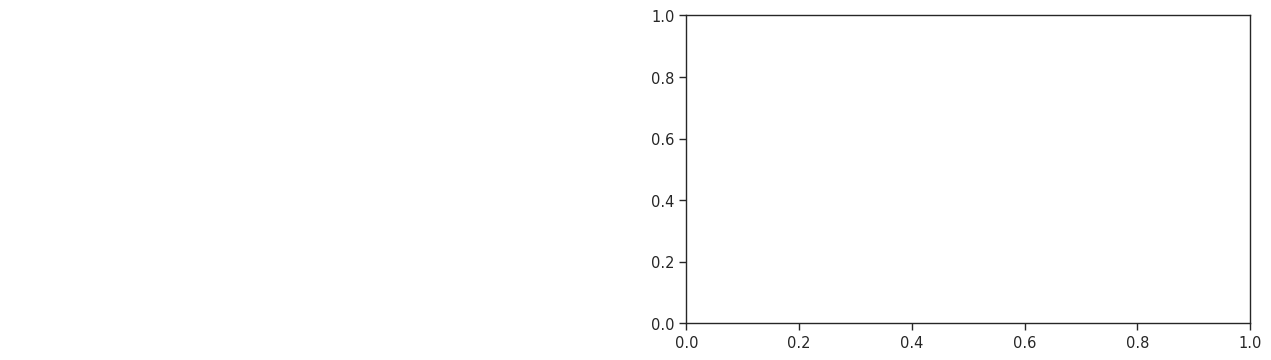

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# ── Panel izquierdo: tabla de resultados ──────────────────────────────────────
ax = axes[0]
ax.axis('off')
cols_show = ['Modelo', 'Tiempo medio (s)', 'Iters reales', 'Mejor F1 CV']
tbl = ax.table(
    cellText   = timing_df[cols_show].values,
    colLabels  = cols_show,
    cellLoc    = 'center',
    loc        = 'center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.1, 1.8)

# Resaltar fila de menor tiempo por grupo (Ridge/Lasso)
for i, row in timing_df.iterrows():
    if 'SAGA' in row['Modelo']:
        tbl[i + 1, 1].set_facecolor('#d4edda')   # verde claro = SAGA más rápido

ax.set_title('Tabla Comparativa: Estándar vs SAGA\n(verde = solver más rápido)',
             fontweight='bold', pad=12)

# ── Panel derecho: barras de tiempo con F1 sobreimpuesto ──────────────────────
ax2 = axes[1]

# Extraer colores dinámicamente según los modelos presentes en timing_df
color_map = {cfg['label']: cfg['color'] for cfg in MODEL_CONFIGS.values()}
colors    = [color_map[m] for m in timing_df['Modelo']]

bars   = ax2.bar(timing_df['Modelo'], timing_df['Tiempo medio (s)'],
                 color=colors, alpha=0.85,
                 yerr=timing_df['Tiempo std  (s)'], capsize=4)

# Etiquetas de F1 sobre cada barra
for bar, f1 in zip(bars, timing_df['Mejor F1 CV']):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + timing_df['Tiempo std  (s)'].max() * 0.15,
        f'F1={f1:.3f}',
        ha='center', va='bottom', fontsize=8, fontweight='bold'
    )

ax2.set_xlabel('Modelo')
ax2.set_ylabel('Tiempo de entrenamiento (s)')
ax2.set_title('Tiempo de Entrenamiento (± std, 5 répéticas)\ncon Mejor C de cada modelo',
              fontweight='bold')
ax2.tick_params(axis='x', rotation=20)
sns.despine(ax=ax2)

plt.tight_layout()
plt.savefig(f'{BASE_PATH}comparacion_standard_vs_saga.png', dpi=150, bbox_inches='tight')
plt.show()


## Sección 10 · Tabla Comparativa Global y Análisis de Convergencia
### 10.1 Tabla de Resultados — Todos los métodos y modelos


       Modelo Método de Búsqueda  Mejor F1-Score (CV)  Tiempo Total Búsqueda (min)  Iteraciones/Evaluaciones ¿Convergió?          Mejor Balanceo
Ridge (lbfgs)        Grid Search               0.0528                         1.30                        24         N/A                   SMOTE
Ridge (lbfgs)      Random Search               0.0530                         3.84                        80         N/A                   SMOTE
 Ridge (SAGA)          Bayesiano               0.0528                        90.84                        30          Sí                   SMOTE
 Ridge (SAGA)    DEAP (Genético)               0.0701                        73.85                        50          Sí class_weight='balanced'


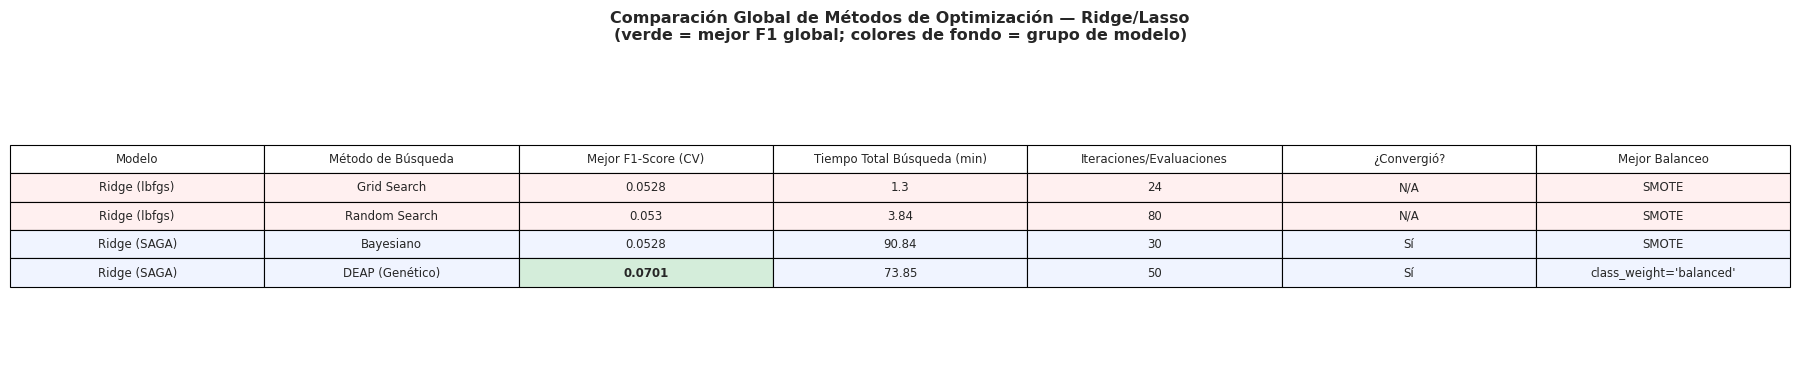

In [50]:
ORDER = [
    'ridge_std_grid',  'ridge_std_random',  'ridge_std_optuna',  'ridge_std_deap',
    'ridge_saga_grid', 'ridge_saga_random', 'ridge_saga_optuna', 'ridge_saga_deap',
    'lasso_std_grid',  'lasso_std_random',  'lasso_std_optuna',  'lasso_std_deap',
    'lasso_saga_grid', 'lasso_saga_random', 'lasso_saga_optuna', 'lasso_saga_deap',
]

rows = []
for k in ORDER:
    if k not in RESULTS:
        continue
    r = RESULTS[k]
    rows.append({
        'Modelo'                   : r['label'],
        'Método de Búsqueda'       : r['method'],
        'Mejor F1-Score (CV)'      : r['best_f1'],
        'Tiempo Total Búsqueda (min)': r['time_min'],
        'Iteraciones/Evaluaciones' : r['n_evals'],
        '¿Convergió?'              : r['converged'],
        'Mejor Balanceo'           : r['best_balance'],
    })

if not rows:
    print("No hay resultados para mostrar en la tabla.")
else:
    comparison_df = pd.DataFrame(rows)
    print(comparison_df.to_string(index=False))

    # Visualización con resaltado del mejor F1 global y por modelo
    display_cols = ['Modelo', 'Método de Búsqueda', 'Mejor F1-Score (CV)',
                    'Tiempo Total Búsqueda (min)', 'Iteraciones/Evaluaciones',
                    '¿Convergió?', 'Mejor Balanceo']

    fig, ax = plt.subplots(figsize=(18, len(rows)*0.5 + 2))
    ax.axis('off')
    tbl = ax.table(
        cellText  = comparison_df[display_cols].values,
        colLabels = display_cols,
        cellLoc   = 'center',
        loc       = 'center',
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8.5)
    tbl.scale(1.05, 1.65)

    # Resaltar mejor F1 global
    best_row = comparison_df['Mejor F1-Score (CV)'].idxmax()
    f1_col   = display_cols.index('Mejor F1-Score (CV)')
    tbl[best_row + 1, f1_col].set_facecolor('#d4edda')
    tbl[best_row + 1, f1_col].set_text_props(fontweight='bold')

    # Color de fondo por grupo de modelo
    model_colors = {
        'Ridge (lbfgs)'      : '#fff0f0',
        'Ridge (SAGA)'       : '#f0f4ff',
        'Lasso (liblinear)'  : '#f0fff0',
        'Lasso (SAGA)'       : '#fffbf0',
    }
    for i, row in comparison_df.iterrows():
        color = model_colors.get(row['Modelo'], 'white')
        for j in range(len(display_cols)):
            if i != best_row or j != f1_col:
                tbl[i + 1, j].set_facecolor(color)

    plt.title('Comparación Global de Métodos de Optimización — Ridge/Lasso\n'
              '(verde = mejor F1 global; colores de fondo = grupo de modelo)',
              fontweight='bold', pad=12)
    plt.tight_layout()
    plt.savefig(f'{BASE_PATH}tabla_comparacion_lr.png', dpi=150, bbox_inches='tight')
    plt.show()


### 10.2 Convergencia Bayesiana (Optuna) — los 4 modelos


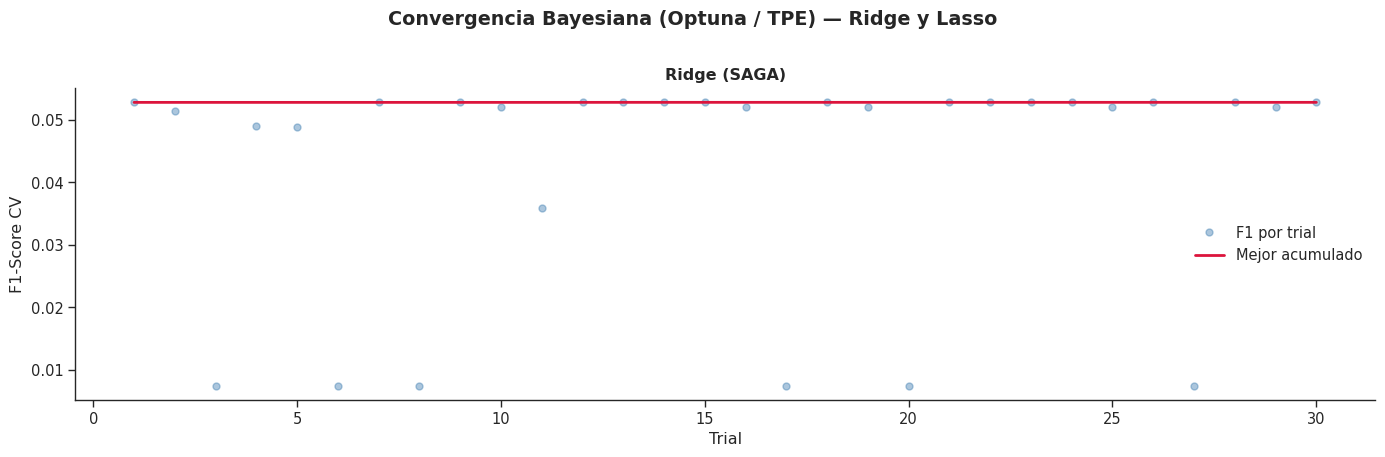

In [51]:
optuna_keys = ['ridge_std_optuna', 'ridge_saga_optuna',
               'lasso_std_optuna', 'lasso_saga_optuna']

valid_optuna = [k for k in optuna_keys if k in RESULTS]

if not valid_optuna:
    print("No hay resultados de Optuna disponibles.")
else:
    n_plots = len(valid_optuna)
    cols = min(2, n_plots)
    rows = (n_plots + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4.5 * rows))
    if n_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for ax, key in zip(axes, valid_optuna):
        r          = RESULTS[key]
        study      = r['study']
        trial_f1   = [t.value for t in study.trials if t.value is not None]
        best_so_far = [max(trial_f1[:i + 1]) for i in range(len(trial_f1))]

        ax.plot(range(1, len(trial_f1) + 1), trial_f1,
                'o', color='steelblue', alpha=0.45, ms=5, label='F1 por trial')
        ax.plot(range(1, len(best_so_far) + 1), best_so_far,
                '-', color='crimson', lw=2, label='Mejor acumulado')
        ax.set_xlabel('Trial')
        ax.set_ylabel('F1-Score CV')
        ax.set_title(r['label'], fontweight='bold')
        ax.legend(frameon=False)
        sns.despine(ax=ax)

    # Ocultar ejes vacíos si los hay
    for i in range(n_plots, len(axes)):
        axes[i].set_visible(False)

    plt.suptitle('Convergencia Bayesiana (Optuna / TPE) — Ridge y Lasso',
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{BASE_PATH}convergencia_optuna_lr.png', dpi=150, bbox_inches='tight')
    plt.show()


### 10.3 Convergencia Genética (DEAP) — los 4 modelos


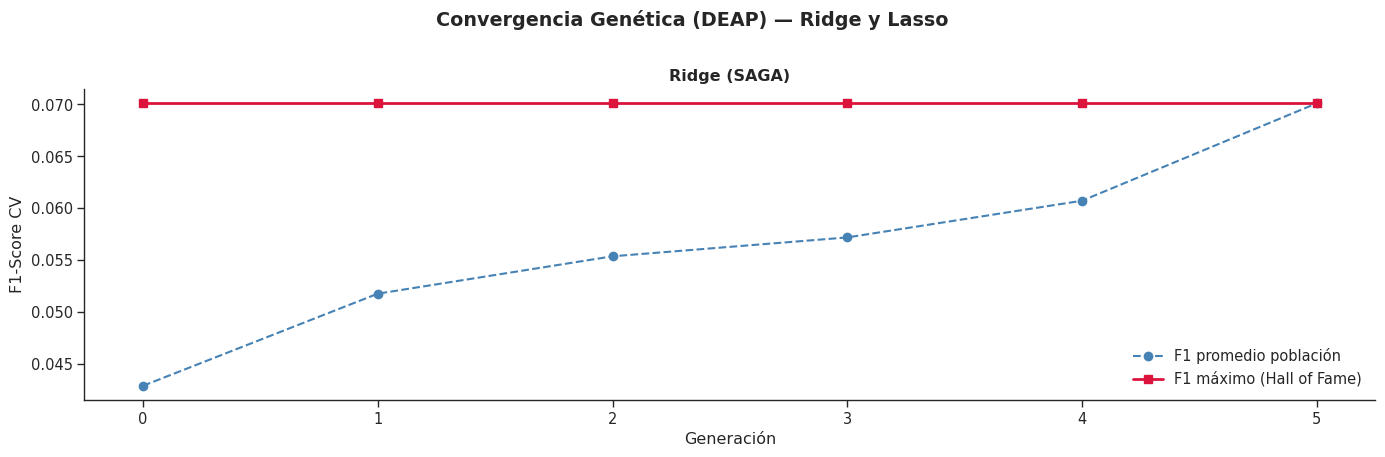

In [52]:
deap_keys = ['ridge_std_deap', 'ridge_saga_deap',
             'lasso_std_deap', 'lasso_saga_deap']

valid_deap = [k for k in deap_keys if k in RESULTS]

if not valid_deap:
    print("No hay resultados de DEAP disponibles.")
else:
    n_plots = len(valid_deap)
    cols = min(2, n_plots)
    rows = (n_plots + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4.5 * rows))
    if n_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for ax, key in zip(axes, valid_deap):
        r    = RESULTS[key]
        lb   = r['logbook']
        gens = lb.select('gen')
        avgs = lb.select('avg')
        maxs = lb.select('max')

        ax.plot(gens, avgs, 'o--', color='steelblue', lw=1.5, ms=6,
                label='F1 promedio población')
        ax.plot(gens, maxs, 's-',  color='crimson',   lw=2,   ms=6,
                label='F1 máximo (Hall of Fame)')
        ax.set_xlabel('Generación')
        ax.set_ylabel('F1-Score CV')
        ax.set_title(r['label'], fontweight='bold')
        ax.legend(frameon=False)
        sns.despine(ax=ax)

    # Ocultar ejes vacíos si los hay
    for i in range(n_plots, len(axes)):
        axes[i].set_visible(False)

    plt.suptitle('Convergencia Genética (DEAP) — Ridge y Lasso',
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{BASE_PATH}convergencia_deap_lr.png', dpi=150, bbox_inches='tight')
    plt.show()


### 10.4 Eficiencia: Calidad vs Costo Computacional


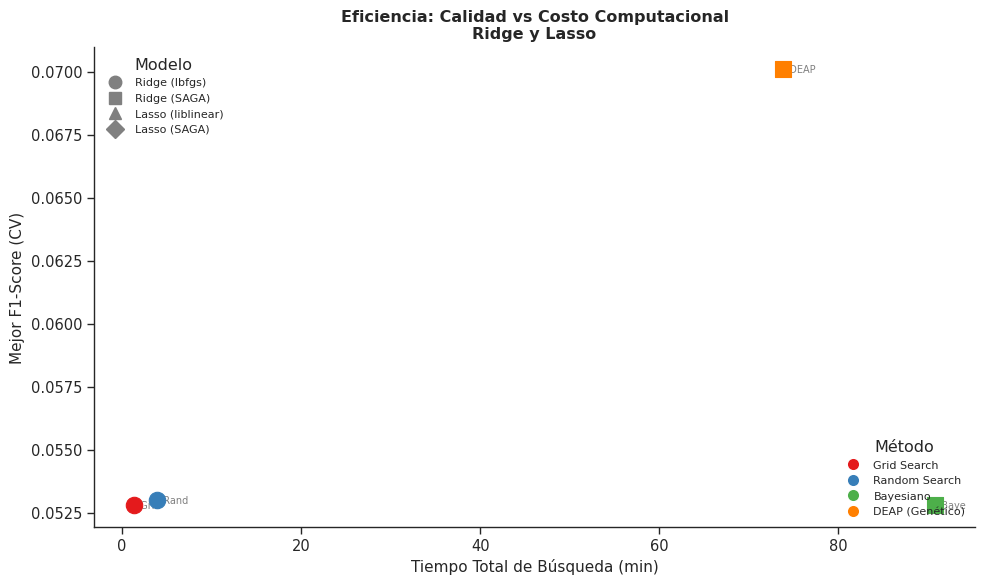

In [53]:
colors_method = {
    'Grid Search'    : '#E41A1C',
    'Random Search'  : '#377EB8',
    'Bayesiano'      : '#4DAF4A',
    'DEAP (Genético)': '#FF7F00',
}
markers_model = {
    'Ridge (lbfgs)'     : 'o',
    'Ridge (SAGA)'      : 's',
    'Lasso (liblinear)' : '^',
    'Lasso (SAGA)'      : 'D',
}

valid_orders = [k for k in ORDER if k in RESULTS]

if not valid_orders:
    print("No hay resultados para mostrar en el gráfico de eficiencia.")
else:
    fig, ax = plt.subplots(figsize=(10, 6))

    for k in valid_orders:
        r = RESULTS[k]
        ax.scatter(
            r['time_min'], r['best_f1'],
            color  = colors_method[r['method']],
            marker = markers_model[r['label']],
            s      = 140, zorder=5,
            label  = f"{r['label']} — {r['method']}",
        )
        ax.annotate(
            f"  {r['method'][:4]}",
            (r['time_min'], r['best_f1']),
            fontsize=7, va='center', color='gray',
        )

    # Leyenda por método
    from matplotlib.lines import Line2D
    legend_method  = [Line2D([0], [0], marker='o', color='w',
                              markerfacecolor=c, markersize=9, label=m)
                      for m, c in colors_method.items()]
    legend_model   = [Line2D([0], [0], marker=mk, color='gray',
                              markersize=9, label=lb, linestyle='None')
                      for lb, mk in markers_model.items()]

    leg1 = ax.legend(handles=legend_method, title='Método', frameon=False,
                     loc='lower right', fontsize=8)
    ax.add_artist(leg1)
    ax.legend(handles=legend_model, title='Modelo', frameon=False,
              loc='upper left', fontsize=8)

    ax.set_xlabel('Tiempo Total de Búsqueda (min)', fontsize=11)
    ax.set_ylabel('Mejor F1-Score (CV)', fontsize=11)
    ax.set_title('Eficiencia: Calidad vs Costo Computacional\nRidge y Lasso',
                 fontweight='bold')
    sns.despine()
    plt.tight_layout()
    plt.savefig(f'{BASE_PATH}eficiencia_lr.png', dpi=150, bbox_inches='tight')
    plt.show()


## Sección 11 · Evaluación Final y Exportación del Mejor Modelo
### 11.1 Identificar la mejor configuración global


In [54]:
best_key = max(RESULTS, key=lambda k: RESULTS[k]['best_f1'])
best_res  = RESULTS[best_key]

print(f"{'═'*62}")
print(f" MEJOR CONFIGURACIÓN GLOBAL — Ridge/Lasso")
print(f"{'═'*62}")
print(f" Modelo         : {best_res['label']}")
print(f" Método búsqueda: {best_res['method']}")
print(f" F1-Score (CV)  : {best_res['best_f1']}")
print(f" Balanceo       : {best_res['best_balance']}")
spec = best_res['spec']
print(f" C              : {spec['C']:.6f}")
print(f" max_iter       : {spec['max_iter']}")
print(f" Solver         : {spec['solver']}")
print(f" Penalización   : {spec['penalty']}")
print(f"{'═'*62}\n")

══════════════════════════════════════════════════════════════
 MEJOR CONFIGURACIÓN GLOBAL — Ridge/Lasso
══════════════════════════════════════════════════════════════
 Modelo         : Ridge (SAGA)
 Método búsqueda: DEAP (Genético)
 F1-Score (CV)  : 0.0701
 Balanceo       : class_weight='balanced'
 C              : 2.042126
 max_iter       : 154
 Solver         : saga
 Penalización   : l2
══════════════════════════════════════════════════════════════



### 11.2 Refit en todo X_train


In [57]:
spec_refit = {
    **spec,               # copia todo lo del ganador
    'solver'  : 'lbfgs',  # único cambio
}

final_model = build_final_model_lr(spec_refit, X_train, y_train)

y_pred_final  = final_model.predict(X_test)
y_proba_final = final_model.predict_proba(X_test)[:, 1]

### 11.3 Evaluación completa en Test


══════════════════════════════════════════════════════════════
 EVALUACIÓN FINAL EN TEST — Ridge (SAGA) — DEAP (Genético)
══════════════════════════════════════════════════════════════
 Accuracy         : 0.9506
 Precision Lavado : 0.0317
 Recall    Lavado : 0.9105
 F1-Score  Lavado : 0.0612
 ROC-AUC          : 0.9827
 PR-AUC           : 0.2621

              precision    recall  f1-score   support

    Legítima       1.00      0.95      0.97   1013870
      Lavado       0.03      0.91      0.06      1798

    accuracy                           0.95   1015668
   macro avg       0.52      0.93      0.52   1015668
weighted avg       1.00      0.95      0.97   1015668



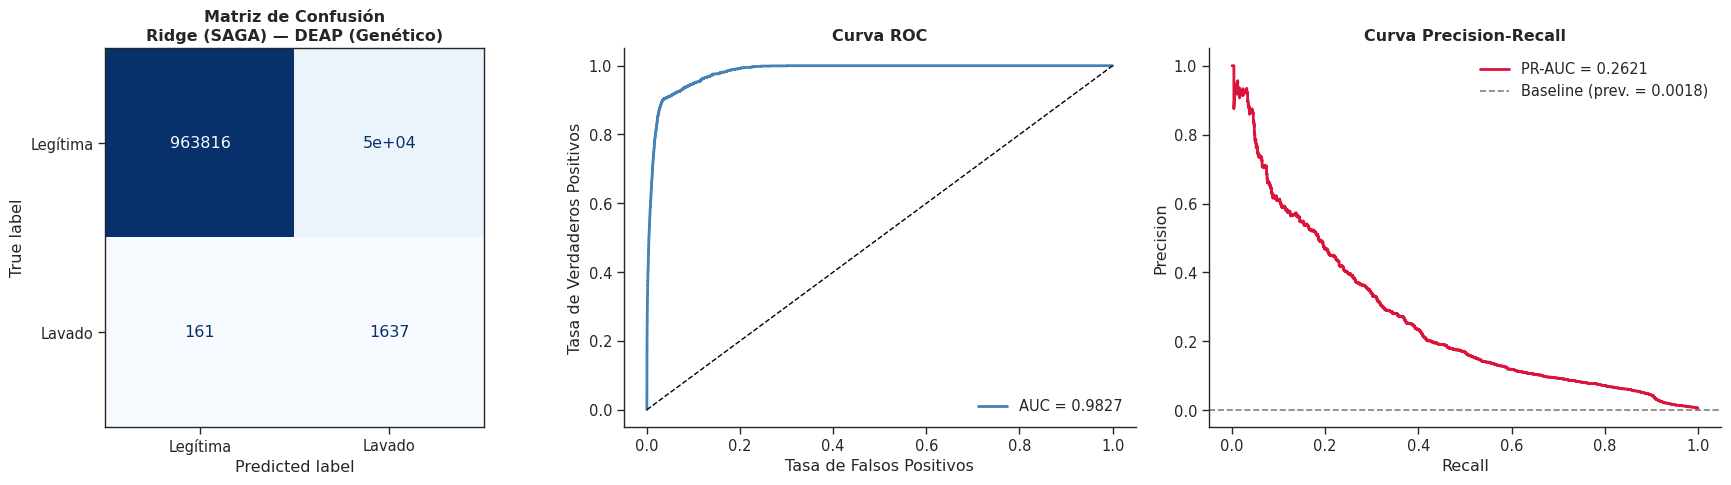

In [58]:
def evaluate_final_model_lr(y_true, y_pred, y_proba, title):
    """Imprime métricas y genera: matriz de confusión, curva ROC, curva PR."""
    report  = classification_report(y_true, y_pred,
                                    target_names=['Legítima', 'Lavado'],
                                    output_dict=True)
    prec_c, rec_c, _ = precision_recall_curve(y_true, y_proba)
    fpr, tpr, _      = roc_curve(y_true, y_proba)
    pr_auc  = auc(rec_c, prec_c)
    roc_auc = auc(fpr, tpr)

    print(f"{'═'*62}")
    print(f" EVALUACIÓN FINAL EN TEST — {title}")
    print(f"{'═'*62}")
    print(f" Accuracy         : {report['accuracy']:.4f}")
    print(f" Precision Lavado : {report['Lavado']['precision']:.4f}")
    print(f" Recall    Lavado : {report['Lavado']['recall']:.4f}")
    print(f" F1-Score  Lavado : {report['Lavado']['f1-score']:.4f}")
    print(f" ROC-AUC          : {roc_auc:.4f}")
    print(f" PR-AUC           : {pr_auc:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Legítima','Lavado'])}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Matriz de confusión
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred),
        display_labels=['Legítima', 'Lavado']
    ).plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title(f'Matriz de Confusión\n{title}', fontweight='bold')

    # Curva ROC
    axes[1].plot(fpr, tpr, lw=2, color='steelblue', label=f'AUC = {roc_auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[1].set_xlabel('Tasa de Falsos Positivos')
    axes[1].set_ylabel('Tasa de Verdaderos Positivos')
    axes[1].set_title('Curva ROC', fontweight='bold')
    axes[1].legend(frameon=False)
    sns.despine(ax=axes[1])

    # Curva Precision-Recall
    axes[2].plot(rec_c, prec_c, lw=2, color='crimson', label=f'PR-AUC = {pr_auc:.4f}')
    axes[2].axhline(y_true.mean(), color='gray', linestyle='--', lw=1.2,
                    label=f'Baseline (prev. = {y_true.mean():.4f})')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].set_title('Curva Precision-Recall', fontweight='bold')
    axes[2].legend(frameon=False)
    sns.despine(ax=axes[2])

    plt.tight_layout()
    plt.savefig(f'{BASE_PATH}evaluacion_final_lr.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {'roc_auc': roc_auc, 'pr_auc': pr_auc}


eval_metrics = evaluate_final_model_lr(
    y_test, y_pred_final, y_proba_final,
    title=f"{best_res['label']} — {best_res['method']}"
)

### 11.4 Exportaciones


In [59]:
pd.DataFrame({'y_proba_lr': y_proba_final}).to_parquet(
    f'{BASE_PATH}y_proba_lr.parquet', index=False
)
joblib.dump(final_model, f'{BASE_PATH}model_lr.joblib')

print(f"\n{'═'*62}")
print(f" Archivos exportados a Drive:")
print(f"   ✓ y_proba_lr.parquet               (para Comparacion_Benchmarks.ipynb)")
print(f"   ✓ model_lr.joblib                  (modelo final serializado)")
print(f"   ✓ comparacion_standard_vs_saga.png (Tabla estándar vs SAGA)")
print(f"   ✓ tabla_comparacion_lr.png         (Tabla global de métodos)")
print(f"   ✓ convergencia_optuna_lr.png       (Convergencia Bayesiana)")
print(f"   ✓ convergencia_deap_lr.png         (Convergencia Genética)")
print(f"   ✓ eficiencia_lr.png                (F1 vs Tiempo)")
print(f"   ✓ evaluacion_final_lr.png          (Métricas finales en Test)")
print(f"{'═'*62}")


══════════════════════════════════════════════════════════════
 Archivos exportados a Drive:
   ✓ y_proba_lr.parquet               (para Comparacion_Benchmarks.ipynb)
   ✓ model_lr.joblib                  (modelo final serializado)
   ✓ comparacion_standard_vs_saga.png (Tabla estándar vs SAGA)
   ✓ tabla_comparacion_lr.png         (Tabla global de métodos)
   ✓ convergencia_optuna_lr.png       (Convergencia Bayesiana)
   ✓ convergencia_deap_lr.png         (Convergencia Genética)
   ✓ eficiencia_lr.png                (F1 vs Tiempo)
   ✓ evaluacion_final_lr.png          (Métricas finales en Test)
══════════════════════════════════════════════════════════════


### Interpretación de Resultados Finales y Negocio AML

Dado que el desafío del **Lavado de Dinero (AML)** es de un desbalanceo extremo, la interpretación de estos modelos de penalización matemática prioriza tres métricas:

1. **Precision-Recall (PR-AUC) vs. ROC-AUC:** En arquitecturas de volumen masivo, el ROC-AUC es frecuentemente un "falso positivo analítico": se infla a niveles altísimos fácilmente (>0.90) porque evalúa el océano de *Verdaderos Negativos*. Nuestro veredicto técnico recae radicalmente en mantener la curva de **PR-AUC consolidada**, ya que se centra exclusivamente en el entorno que reacciona a fraudes (*recall*) ante alertas verídicas (*precision*).
2. **Recall vs Falsas Alarmas (Precision):** La Matriz de Confusión expone el comportamiento del clasificador (si resulta muy laxo y genera miles de falsos positivos o muy restringido perdiéndose el fraude). La optimización penalizada (vía multiplicadores C en Ridge) controla teóricamente ese nivel, evitando colapsar al equipo humano del Banco con alertas inválidas pero sin arriesgar perder la red transaccional espuria.